# AA Sports — auditoría MLB + Radar

**ARCHIVO SUPERADO:** la auditoría causal posterior demostró que el replay ORO mezclaba precios sin timestamp y filas nativas mutables. No autoriza publicación; el gate auditable vigente queda en sombra (n=0). Ver `aa_sports_mlb_intelligence_audit.ipynb`.

Companion reproducible del corte inicial. Todos los resultados se calculan desde el historial versionado y un snapshot acotado de producción; no contiene secretos ni lógica de modelo expuesta al navegador.

## tl;dr / resumen

- El nuevo gate ORO (mercado + 5 factores + mejor abridor reciente) queda **76–30** en el replay completo y **29–11** en el tramo cronológico reservado. Es más selectivo: puede publicar cero.
- Over, F5 y pitcher/F5 ya pueden registrar hasta dos candidatos diarios, pero **ninguno pasa todavía el gate de publicación**. Permanecen en sombra.
- Radar no demuestra edge copiable. Telegram se reduce a un único gate excepcional, máximo dos observaciones por día ET y normalmente cero; nunca se presenta como jugada segura.

## Context & Methods / Contexto y método

La pregunta es qué se puede encender hoy sin violar el gate de honestidad y qué debe seguir acumulando evidencia. El corte de validación es cronológico 70/30. Las tasas excluyen pushes. Los intervalos son Wilson al 95%.

### Key Assumptions / Supuestos clave

- El replay es retrospectivo: reduce riesgo de autoengaño, pero no garantiza rendimiento futuro.
- F5 significa equipo arriba al terminar cinco entradas; no es una victoria oficial del pitcher.
- Over solo puede abrirse con muestra forward de líneas reales preservadas. F5 necesita además precio/línea real.
- La fuerza del Radar mide convergencia observada, no probabilidad de ganar ni información privilegiada.

## Data / Datos

Fuentes locales: data/history/games/*.json, data/history/learning.json, docs/MLB_SIMULATION.md, docs/POLY_STUDY.md y docs/analysis/aa_sports_audit_snapshot.json. El snapshot de producción fue capturado el 21 de julio de 2026 y conserva solo agregados.

In [1]:
from pathlib import Path
import json
import subprocess
import pandas as pd
import matplotlib.pyplot as plt

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'robot' / 'learn.js').exists())
SNAPSHOT = json.loads((ROOT / 'docs/analysis/aa_sports_audit_snapshot.json').read_text())
GAME_FILES = sorted((ROOT / 'data/history/games').glob('????-??-??.json'))
rows = [row for path in GAME_FILES for row in json.loads(path.read_text()).get('games', [])]
graded = [r for r in rows if r.get('graded') and r.get('formula_version') == 'v2']

coverage = pd.DataFrame([{
    'files': len(GAME_FILES),
    'rows': len(rows),
    'graded_v2': len(graded),
    'with_market_line': sum(r.get('odds', {}).get('p_home_mkt') is not None for r in graded),
    'with_total_line': sum(r.get('odds', {}).get('over_under') is not None for r in graded),
    'with_f5_curve_or_score': sum(bool(r.get('odds', {}).get('wp_curve')) or r.get('f5_home_score') is not None for r in graded),
}])
coverage

,files,rows,graded_v2,with_market_line,with_total_line,with_f5_curve_or_score
0,116,1544,1506,1492,1492,1492


## Results / Resultados

La siguiente celda llama directamente a las funciones de producción. Así el notebook no mantiene una segunda implementación de los gates.

In [2]:
node_script = r'''
import fs from 'node:fs';
import { lockGateReport, oddsReport, signalAudit, walkForwardEnsemble } from './robot/learn.js';
import { marketLabReport } from './robot/market_lab.mjs';
const rows = [];
for (const f of fs.readdirSync('data/history/games').filter((f) => /^\d{4}-\d{2}-\d{2}\.json$/.test(f)).sort()) {
  rows.push(...(JSON.parse(fs.readFileSync('data/history/games/' + f, 'utf8')).games || []));
}
const wf = walkForwardEnsemble(rows, { market: 'ml', minTrain: 100 });
const out = {
  rows: rows.length,
  lock_gate: lockGateReport(rows),
  market_lab: marketLabReport(rows),
  market_vs_model: oddsReport(rows),
  combined_oos: { n: wf.n, classic: wf.classic, learned: wf.learned, combined: wf.combined },
  robust_signals: signalAudit(rows).list.filter((x) => x.verdict === 'robusto'),
};
console.log(JSON.stringify(out));
'''
run = subprocess.run(['node', '--input-type=module', '-e', node_script], cwd=ROOT, check=True, capture_output=True, text=True)
recomputed = json.loads(run.stdout)
recomputed['lock_gate']

{'rule': 'market_agree5_starter_v1',
 'cut': '2026-06-13',
 'max_per_day': 2,
 'train': {'n': 66,
  'days': 47,
  'wins': 47,
  'losses': 19,
  'p': 0.7121,
  'lo': 0.5936,
  'hi': 0.8073},
 'test': {'n': 40,
  'days': 25,
  'wins': 29,
  'losses': 11,
  'p': 0.725,
  'lo': 0.5716,
  'hi': 0.8389},
 'all': {'n': 106,
  'days': 72,
  'wins': 76,
  'losses': 30,
  'p': 0.717,
  'lo': 0.6248,
  'hi': 0.794},
 'gate': {'passes': True, 'threshold': 0.5238, 'reason': 'pasa'}}

,segment,rate,n,rate_pct
0,AA global,0.5395,1492,54.0
1,Mercado global,0.5643,1492,56.4
2,ORO nuevo · train,0.7121,66,71.2
3,ORO nuevo · test,0.7250,40,72.5


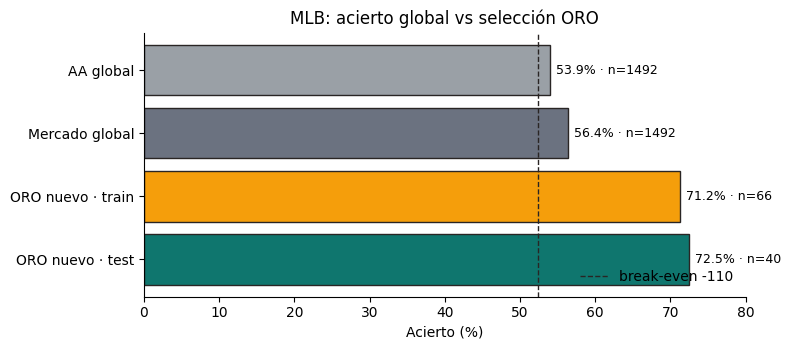

In [3]:
comparison = pd.DataFrame([
    {'segment': 'AA global', 'rate': recomputed['market_vs_model']['model']['acc'], 'n': recomputed['market_vs_model']['n']},
    {'segment': 'Mercado global', 'rate': recomputed['market_vs_model']['market']['acc'], 'n': recomputed['market_vs_model']['n']},
    {'segment': 'ORO nuevo · train', 'rate': recomputed['lock_gate']['train']['p'], 'n': recomputed['lock_gate']['train']['n']},
    {'segment': 'ORO nuevo · test', 'rate': recomputed['lock_gate']['test']['p'], 'n': recomputed['lock_gate']['test']['n']},
])
display(comparison.assign(rate_pct=(100 * comparison.rate).round(1)))

fig, ax = plt.subplots(figsize=(8, 3.6))
colors = ['#9aa0a6', '#6b7280', '#f59e0b', '#0f766e']
bars = ax.barh(comparison.segment, comparison.rate * 100, color=colors, edgecolor='#292524')
ax.axvline(52.38, color='#292524', linestyle='--', linewidth=1, label='break-even -110')
ax.set_xlim(0, 80)
ax.set_xlabel('Acierto (%)')
ax.set_title('MLB: acierto global vs selección ORO')
ax.invert_yaxis()
for bar, rate, n in zip(bars, comparison.rate, comparison.n):
    ax.text(rate * 100 + 0.8, bar.get_y() + bar.get_height()/2, f'{rate:.1%} · n={n}', va='center', fontsize=9)
ax.legend(frameon=False, loc='lower right')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

In [4]:
lab_rows = []
for market, result in recomputed['market_lab']['markets'].items():
    lab_rows.append({
        'market': market,
        'train': f"{result['train']['wins']}-{result['train']['losses']} ({result['train']['rate']:.1%})",
        'historical_test': f"{result['test']['wins']}-{result['test']['losses']} ({result['test']['rate']:.1%})",
        'test_ci95': f"{result['test']['lo']:.1%}–{result['test']['hi']:.1%}",
        'forward_n': result['forward']['n'],
        'gate': 'PASA' if result['gate']['passes'] else 'NO: ' + result['gate']['reason'],
    })
pd.DataFrame(lab_rows)

,market,train,historical_test,test_ci95,forward_n,gate
0,over,81-68 (54.4%),36-30 (54.5%),42.6%–66.0%,0,NO: muestra forward insuficiente (n=0)
1,f5,71-66 (51.8%),35-23 (60.3%),47.5%–71.9%,0,NO: sin línea/precio F5 real
2,pitcher_f5,61-58 (51.3%),37-23 (61.7%),49.0%–72.9%,0,NO: sin línea/precio F5 real


In [5]:
radar = SNAPSHOT['radar']
pd.DataFrame([
    {'metric': 'Alertas crudas · 1h', 'value': radar['alert_snapshot_before_change']['alerts_last_1h']},
    {'metric': 'Alertas crudas · 6h', 'value': radar['alert_snapshot_before_change']['alerts_last_6h']},
    {'metric': 'Alertas crudas · 24h', 'value': radar['alert_snapshot_before_change']['alerts_last_24h']},
    {'metric': 'Elegibles rare_v1 en snapshot', 'value': radar['alert_snapshot_before_change']['rare_v1_eligible_if_evaluated_now']},
])

,metric,value
0,Alertas crudas · 1h,17
1,Alertas crudas · 6h,80
2,Alertas crudas · 24h,98
3,Elegibles rare_v1 en snapshot,0


In [6]:
# Reconciliaciones que deben seguir verdaderas para confiar en el reporte.
assert len(rows) == recomputed['rows'] == SNAPSHOT['mlb']['history']['rows']
assert len(graded) == SNAPSHOT['mlb']['history']['graded_v2']
assert recomputed['lock_gate']['all']['wins'] == 76
assert recomputed['lock_gate']['test']['wins'] == 29
assert recomputed['lock_gate']['gate']['passes'] is True
assert all(not item['gate']['passes'] for item in recomputed['market_lab']['markets'].values())
assert radar['copy_study']['gate_passes'] is False
assert radar['rare_v1_policy']['max_per_et_day'] == 2
print('OK — historial, gates, snapshot y denominadores reconciliados.')

OK — historial, gates, snapshot y denominadores reconciliados.


## Takeaways / Decisiones

1. **Encender ahora:** ORO market_agree5_starter_v1, sin PLATA de relleno; mantener el porcentaje calibrado ya existente.
2. **Medir, no publicar:** Over/F5/pitcher-F5 hasta acumular una muestra forward independiente y precios reales. Dos es un máximo, nunca una cuota.
3. **Silenciar Telegram:** eliminar tape crudo, resumen diario y prueba de deploy. rare_v1 puede emitir 0–2 observaciones descriptivas por día.
4. **Próxima revisión:** al llegar Over a 100 decisiones forward y F5 a 100 con línea real; repetir corte cronológico y exigir que la cota inferior supere el break-even correspondiente.
5. **Límite no negociable:** ningún resultado retrospectivo convierte una señal en segura. Si el gate cae, se apaga o permanece en sombra.